---
##  Getting the Data 

### Downloading historical stock data with Yahoo Finance

**Why Yahoo Finance / `yfinance`?**
- It's free, doesn't need an API key, and gives clean daily OHLCV data going back many years.
- It covers Indian tickers too — NSE-listed stocks use the suffix `.NS` (e.g. `RELIANCE.NS`), and indices like NIFTY 50 are available as `^NSEI`, BANK NIFTY as `^NSEBANK`.

**Why start with the NIFTY 50 index instead of a single stock?**
An index is an *average* of many large companies, so it's less noisy and gives a cleaner first look at "overall market behavior" — which is exactly what microstructure analysis cares about. Later, you can swap in individual stocks (e.g. `RELIANCE.NS`, `TCS.NS`) using the same code.

> **Note:** This cell needs an active internet connection to reach Yahoo Finance's servers. Run it in your own Jupyter Notebook / Google Colab environment. If `yfinance` isn't installed, uncomment the pip install line below.


In [1]:
!pip install yfinance   

import yfinance as yf
import pandas as pd


TICKER = "^NSEI"         
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"

# auto_adjust=False keeps BOTH "Close" and a separate "Adj Close" column.
# (Newer yfinance versions default to auto_adjust=True, which silently REMOVES
# "Adj Close" and pre-adjusts "Close" instead -- we want to see and use both explicitly.)
df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False)

# Recent yfinance versions return MultiIndex columns like ('Close', '^NSEI') even for
# a single ticker. If we don't flatten this before saving to CSV, reading the CSV back
# later misreads the extra header row as a data row -- corrupting every column to
# "object" dtype. Flattening now avoids that problem completely.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


df.to_csv("nifty50_data.csv")

print(f"Downloaded {df.shape[0]} rows and {df.shape[1]} columns for {TICKER}")
print("Columns:", list(df.columns))
df.head()


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed

Downloaded 2459 rows and 6 columns for ^NSEI
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800


**What just happened, line by line:**
- `import yfinance as yf` → loads the library that talks to Yahoo Finance's servers.
- `TICKER = "^NSEI"` → we store the symbol in a variable instead of hardcoding it everywhere. This is good practice: if you want to analyze a different stock later, you change **one line**, not every line of code.
- `yf.download(..., auto_adjust=False)` → sends a request to Yahoo Finance and returns a Pandas DataFrame (a table) of daily prices between our chosen dates. We explicitly set `auto_adjust=False` because newer versions of `yfinance` default to `auto_adjust=True`, which silently drops the separate `Adj Close` column (it pre-adjusts `Close` instead). We want both columns visible and explicit, since Step 4 depends on `Adj Close` existing.
- The `if isinstance(df.columns, pd.MultiIndex): ...` block → newer `yfinance` versions return **two-level column names** (e.g. `("Close", "^NSEI")`) even when you only ask for one ticker. If we don't flatten this to a normal single-level column name *before* saving to CSV, reading the file back later gets confused by the extra header row and turns every column into text (`object` dtype) instead of numbers. Flattening now prevents that entirely.
- `df.to_csv(...)` → saves the data to your computer. This means if Yahoo Finance is slow or down later, you can just reload this CSV instead of re-downloading.
- `df.head()` → shows the first 5 rows so we can sanity-check the data looks right.

> 💡 **If you already downloaded data before this fix and are seeing all your columns show up as `object` dtype with a `KeyError` on `Adj Close`:** just re-run the fixed download cell above to overwrite `nifty50_data.csv` with a clean version, then re-run Step 5's loading cell.

###  Understanding every column

When you run the cell above, the DataFrame will have these columns. Here's what each one means, in plain language:

| Column | Meaning | Beginner analogy |
|---|---|---|
| **Date** | The trading day this row represents | Like a diary entry — one entry per market day (weekends & holidays are skipped, since markets are closed) |
| **Open** | The price at which the very first trade of the day happened | The price "haggling" started at, when the market opened at 9:15 AM IST |
| **High** | The highest price reached at any point during the day | The most anyone was willing to pay that day |
| **Low** | The lowest price reached at any point during the day | The lowest anyone was willing to sell for that day |
| **Close** | The price at which the last trade of the day happened | The final agreed price when the market closed at 3:30 PM IST |
| **Adj Close** | The closing price, *adjusted* for things like dividends and stock splits | Makes prices comparable across time — e.g., if a stock splits 2-for-1, the raw price halves overnight, but Adj Close corrects for that so your returns calculation isn't thrown off |
| **Volume** | The total number of shares traded that day | How "busy" the market was for that stock/index that day — a proxy for liquidity |

**Why "Adj Close" matters so much in microstructure/return analysis:**
If a company pays a dividend or does a stock split, the *raw* Close price can jump or drop for reasons that have nothing to do with market sentiment. If we calculated daily returns using raw Close, we'd see a fake "crash" on split days. Adj Close removes this distortion — which is why we'll use **Adj Close** (not Close) whenever we calculate returns later.


1. **Using `Close` instead of `Adj Close` for return calculations** — leads to fake spikes/crashes around split or dividend dates.
2. **Forgetting that markets are closed on weekends/holidays** — beginners sometimes "fill" missing dates incorrectly, assuming data is missing/corrupted when really the market just didn't trade that day.
3. **Not saving a local CSV** — re-downloading from Yahoo Finance every time you rerun the notebook is slow and can fail if you lose internet access mid-project.


---
## Loading the Data & Inspecting It 

### Loading the dataset

Now that we've downloaded and saved our data, we load it back from the CSV file. **Why load from CSV instead of downloading fresh every time?**
- It's much faster.
- It keeps your analysis **reproducible** — everyone on your team analyzes the exact same snapshot of data, even if Yahoo Finance's numbers get revised later.
- It works even without internet access.


In [2]:
import pandas as pd
df = pd.read_csv("nifty50_data.csv", index_col=0, parse_dates=True)
df.index.name = "Date"
df.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800


**Code Explaination Line by line:**
- `pd.read_csv(...)` → reads the CSV file back into a DataFrame.
- `index_col=0` → tells Pandas that the first column (our dates) should become the DataFrame's index, not a regular column. This makes time-based operations (like plotting a time series or resampling by month) much easier later.
- `parse_dates=True` → converts that index from plain text (e.g. `"2015-01-02"`) into an actual `datetime` type, so Pandas understands it as a real date and not just a string.
- `df.index.name = "Date"` → just a cosmetic touch so our index column is clearly labeled when we print things.

###  Data Inspection

Before touching or cleaning anything, we always **inspect** the data first. This is a non-negotiable habit in data science — you should never clean or analyze a dataset you haven't looked at carefully.


In [3]:
# Shape: Checks how many rows (days) and columns (features) we have.
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (2459, 6)


 `df.info()` matters: It's the single most useful "first look" command in Pandas. It tells you three things simultaneously:
- **Column names** — confirms Open/High/Low/Close/Adj Close/Volume are all present and spelled correctly.
- **Non-Null Count** — if a column shows fewer non-null values than total rows, you have missing data (more on this below).
- **Dtype** — confirms numeric columns are actually stored as numbers (`float64`), not accidentally as text (`object`). This is a very common beginner trap explained further down.


In [4]:
# 2. Info: column names, non-null counts, and data types all at once
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2459 entries, 2015-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2459 non-null   float64
 1   Close      2459 non-null   float64
 2   High       2459 non-null   float64
 3   Low        2459 non-null   float64
 4   Open       2459 non-null   float64
 5   Volume     2459 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 134.5 KB


In [5]:
# 3. Describe: statistical summary of all numeric columns
df.describe()


,Adj Close,Close,High,Low,Open,Volume
count,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2.459000e+03
mean,13506.704131,13506.704131,13578.560372,13431.631915,13516.667489,3.223233e+05
std,4967.729528,4967.729528,4986.944771,4946.175825,4968.505490,1.949277e+05
min,6970.600098,6970.600098,7034.200195,6825.799805,7023.649902,0.000000e+00
25%,9347.000000,9347.000000,9423.325195,9299.875000,9375.750000,1.943000e+05
50%,11515.200195,11515.200195,11573.000000,11451.250000,11531.599609,2.624000e+05
75%,17531.450195,17531.450195,17622.575195,17422.250000,17530.674805,3.843000e+05
max,26216.050781,26216.050781,26277.349609,26151.400391,26248.250000,1.811000e+06


**How to read `df.describe()`:**
- **count** → how many non-missing values exist per column (should roughly match your row count).
- **mean / std** → the average price/volume and how spread out (volatile) it is.
- **min / max** → sanity-check for impossible values — e.g. a negative price or negative volume would indicate a data error.
- **25% / 50% / 75%** (quartiles) → gives a feel for the typical range without being thrown off by a few extreme outlier days.

This is also a great moment to catch data errors: if `min` for `Volume` is `0` or negative, or `High` is somehow *lower* than `Low` on some day, that's a red flag we'll deal with in (Data Cleaning).


In [6]:
# Missing values: Checkhow many empty cells does each column have.
df.isnull().sum()


Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

**Why missing values happen in stock data:**
- Yahoo Finance can occasionally have small gaps for specific dates (server issues, corporate actions, etc.).
- They are usually rare in daily index data, but it's still essential to check — a model or plot built on top of unexpected `NaN` values can silently produce wrong results (e.g. a moving average calculation skipping days without warning you).


In [7]:
#  Duplicate rows: are there any exact repeated rows?
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


**Why duplicates matter:** A duplicated row means the same trading day's data appears twice. If left in, it can silently bias your statistics (e.g. a volatile day would be "double-counted" in averages and standard deviations) and mess up time-series plots (two points for one date).


1. **Skipping inspection and jumping straight to plots/models.** Always run shape → info → describe → missing values → duplicates, in that order, before doing anything else.
2. **Ignoring the dtype of numeric columns.** If `Close` shows up as `object` instead of `float64`, Pandas is treating your prices as text — any math on that column will either crash or silently misbehave. This is very often caused by the `yfinance` MultiIndex column issue described in Step 3 — if you see this, re-check that your download cell flattened `df.columns` before saving to CSV.
3. **Assuming "no missing values shown = perfectly clean data."** `isnull().sum()` only catches *empty* cells — it won't catch things like a `High` price that's impossibly lower than `Low`, which is a logical error rather than a missing value. We'll specifically check for these logical errors in the next milestone (Data Cleaning).


---
##  Data Cleaning

 Cleaning always follows inspection — never the other way around, because you need to know what problems exist before deciding how to fix them.

cleaning order: **duplicates → missing values → logical errors → data types → sorting.**

### 1. Removing duplicate rows

 Now we drop them.


In [8]:
# Remove fully duplicated rows, keeping the first occurrence
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")


Removed 0 duplicate rows


**Why `keep the first occurrence`?** When a row is duplicated, both copies contain identical data, so it doesn't matter which one we keep — we just need exactly one. Keeping the first is the conventional default.

### 2. Handling missing values

For stock price data, there's an important rule: **never fill missing prices with the column mean or median.** Why? Because a stock price on a missing day is not "some average price" — it's most likely very close to the price on the day *right before or after* it. Using the overall mean would insert an unrealistic, disconnected value into a smooth time series and would distort any return/volatility calculation around that date.

The standard, sensible approach for time-series price data is **forward-fill**: carry the last known value forward until a new value appears.


In [9]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Forward-fill: carry the last valid price/volume forward
df = df.ffill()

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Missing values after cleaning:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


**Why forward-fill and not backward-fill?** Forward-fill only uses *past* information to fill a gap — which mirrors reality (on the day data was missing, the most recent known price *was* still the last traded price). Backward-fill would use *future* information, which doesn't reflect what was actually knowable at that point in time — this is a subtle form of "lookahead bias," a mistake that's especially dangerous in any finance project.

> If a `NaN` happens to be the very first row (no previous value to carry forward), forward-fill can't fix it. In that rare case, dropping that single row (`df.dropna()`) is the simplest safe option.

### Checking for logical errors

Missing values aren't the only kind of "bad" data. Stock data can have **logically impossible** rows that still contain numbers — for example, a day where `High` is somehow *lower* than `Open` or `Close`. By definition, `High` must be the maximum of the day and `Low` must be the minimum, so any violation of that is a data error, not a missing value, which is why `isnull()` alone couldn't catch it.


In [10]:
# A valid trading day must satisfy: Low <= Open, Close <= High
invalid_rows = df[
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"])
]

print(f"Found {len(invalid_rows)} logically inconsistent rows")
invalid_rows


Found 0 logically inconsistent rows


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,


If this finds any rows, the safest beginner-friendly fix is usually to **drop them** (since fixing them would mean guessing the "correct" true price, which we can't know) — unless there are only a handful, in which case dropping a few rows out of thousands has negligible impact on the analysis:


In [11]:
df = df.drop(index=invalid_rows.index)
print("Shape after removing logically inconsistent rows:", df.shape)


Shape after removing logically inconsistent rows: (2459, 6)


###  Fixing data types

Even after cleaning values, it's worth double-checking every column has the *correct* type — numbers should be `float64`/`int64`, never `object` (text).


In [12]:
print(df.dtypes)

# If any price/volume column were accidentally stored as text, this converts it to numeric
# (errors="coerce" turns any unconvertible text into NaN, so we can catch it rather than crash)
for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop any new NaNs that may have appeared from forcing conversion (should normally be zero)
df = df.dropna()


Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object


###  Sorting by date

Time-series analysis (moving averages, returns, lag features — all coming up soon) assumes rows are in **chronological order**. It's easy to accidentally break this order after dropping/filtering rows, so we explicitly re-sort as a safety net.


In [13]:
df = df.sort_index()
print("Final cleaned shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
df.head()


Final cleaned shape: (2459, 6)
Date range: 2015-01-02 00:00:00 to 2024-12-31 00:00:00


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800



1. **Filling missing prices with `mean()` or `median()`.** This ignores the time-series nature of the data and can insert unrealistic values.
2. **Using backward-fill (`bfill`) without realizing it introduces lookahead bias** — using information that wasn't actually available at that point in time. This is one of the most serious mistakes in any finance/ML project because it can make your model look far more accurate than it really is.
3. **Only checking `isnull()` and assuming that's "cleaning done."** Logical errors (like High < Low) don't show up as missing values — you have to explicitly check business-logic rules for your specific data.
4. **Cleaning data in the wrong order** — e.g., sorting before removing duplicates can waste effort; always duplicates → missing values → logical checks → dtypes → sort, as we did above.


---
## Exploratory Data Analysis (part-1)

**Why EDA matters:** Before building any features or models, we need to *see* the data's shape and behavior with our own eyes. EDA helps us catch outliers, understand typical ranges, and form early hypotheses (e.g. "volatility looks higher after 2020") that we'll test more rigorously later.


- **Part 1 (this milestone):** Time Series Visualization + Univariate Analysis (distributions, boxplots)
- **Part 2 (next):** Bivariate Analysis, Correlation Heatmaps, Volume Analysis
- **Part 3 (after that):** Daily Return Analysis, Volatility Analysis, Moving Average Analysis




### Setting up our plotting libraries

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# A clean, readable default style for all our plots
sns.set_style("whitegrid")

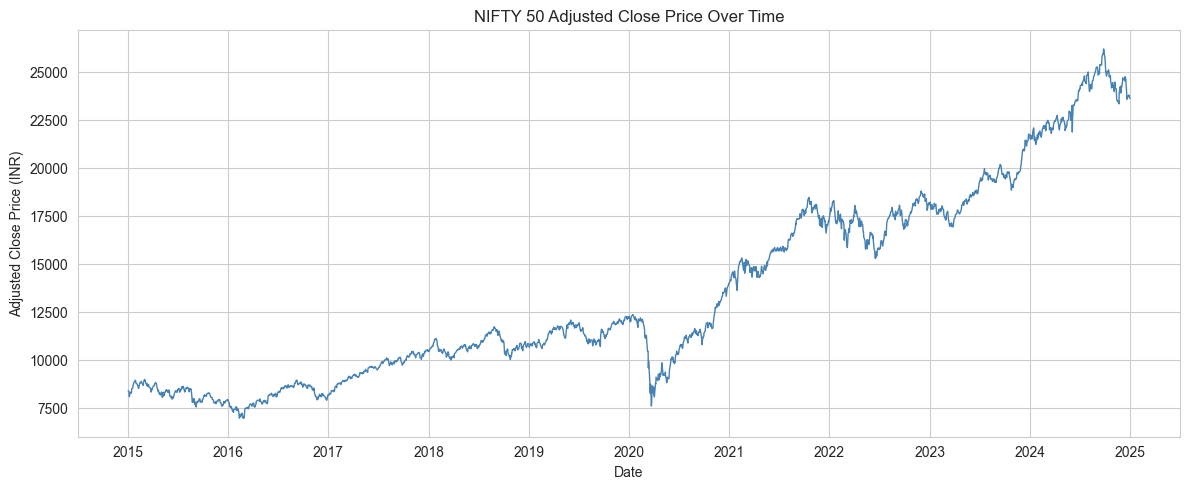

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"], color="steelblue", linewidth=1)
plt.title("NIFTY 50 Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (INR)")
plt.tight_layout()
plt.show()


**How to interpret this chart:**
- An **overall upward slope** over many years reflects long-term market growth — expected for a broad index like NIFTY 50.
- **Sharp, sudden drops** (e.g., around early 2020) usually correspond to major shocks (like COVID-19) — worth noting as candidate "high volatility" periods we'll investigate quantitatively later.
- **Flatter, sideways stretches** suggest calmer, range-bound periods — a possible different "market regime."


### Univariate Analysis: Distribution Plots

**Why look at distributions?** A time series shows *when* things happened; a distribution plot shows *how often* different values occur, regardless of when. This helps answer: "Is the price data roughly symmetric, or skewed? Are there unusually extreme days?"


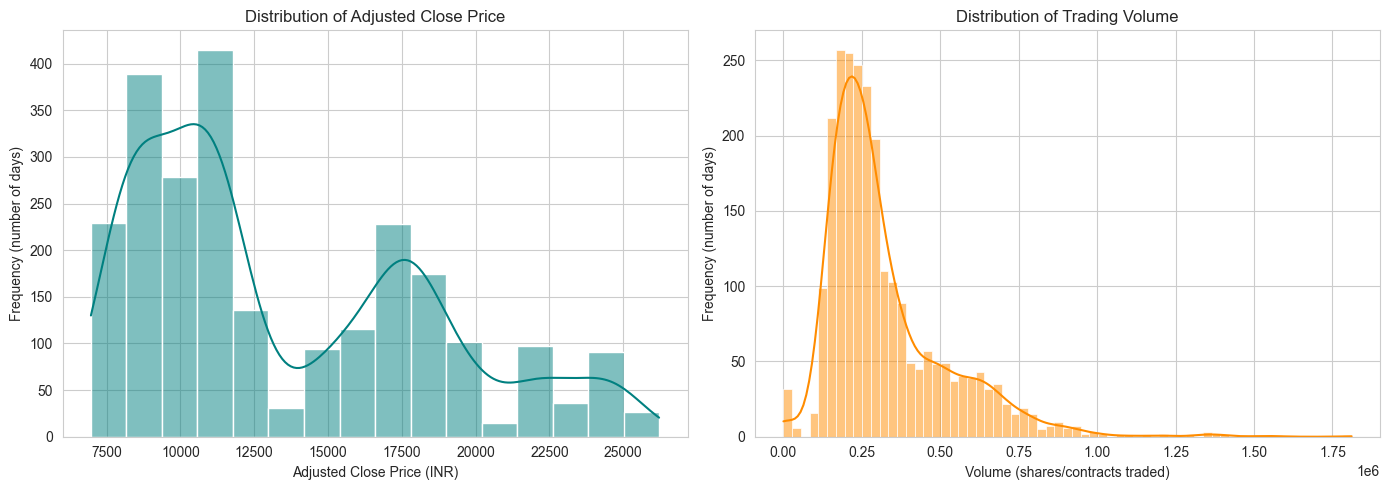

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Adj Close"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Adjusted Close Price")
axes[0].set_xlabel("Adjusted Close Price (INR)")
axes[0].set_ylabel("Frequency (number of days)")

sns.histplot(df["Volume"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Trading Volume")
axes[1].set_xlabel("Volume (shares/contracts traded)")
axes[1].set_ylabel("Frequency (number of days)")

plt.tight_layout()
plt.show()



- `sns.histplot(..., kde=True, ...)` → draws a histogram (bars showing how many days fall into each price/volume "bucket") plus a smooth KDE curve (Kernel Density Estimate) overlaid on top, which makes the overall shape easier to see than bars alone.
- We use `subplots(1, 2, ...)` to place Price and Volume side-by-side for easy comparison, since they're on very different scales and shouldn't share one axis.

**How to interpret these charts:**
- **Adjusted Close distribution:** For a long price history, this is often **not** a simple bell curve — it can be spread out or multi-peaked, because the index has traded at genuinely different price levels across different years (e.g., much lower a decade ago than recently). This is expected and different from a "bad" distribution.
- **Volume distribution:** Often **right-skewed** (a long tail toward high values) — most days have "typical" volume, but a handful of high-news-impact days have unusually large volume. This tail is exactly the kind of day we're interested in for microstructure analysis.

### Univariate Analysis: Boxplots

**Why boxplots in addition to histograms?** A boxplot is a compact summary that makes **outliers** immediately visible using a simple, standardized rule (points beyond 1.5× the interquartile range are flagged as outliers) — histograms show shape, but boxplots are better at flagging "how extreme are the extreme days?"


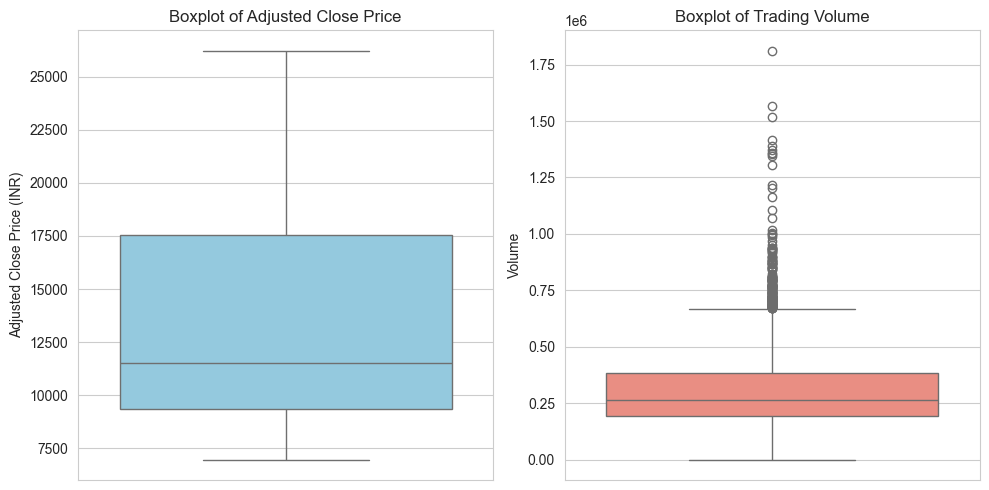

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(y=df["Adj Close"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot of Adjusted Close Price")
axes[0].set_ylabel("Adjusted Close Price (INR)")

sns.boxplot(y=df["Volume"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of Trading Volume")
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()


**How to interpret a boxplot:**
- The **box** covers the middle 50% of days (25th to 75th percentile) — the "typical" range.
- The **line inside the box** is the median.
- The **whiskers** extend to the normal range of data.
- Individual **dots beyond the whiskers** are statistical outliers — for Volume, these are usually the high-activity days we flagged in the histogram; for Price, isolated outlier dots are less meaningful (price naturally drifts over a decade) — this is a good example of a chart needing *context* (in this case, the time series above) rather than being read in isolation.




##  Exploratory Data Analysis — Part 2 (continued)
We looked at each variable **on its own** (univariate analysis). Now we look at **relationships between variables** (bivariate analysis), summarize all relationships at once with a **correlation matrix**, and dig deeper into **Volume Analysis** specifically.

### Bivariate Analysis: Price vs. Volume

**Why compare price and volume together?** In market microstructure, a core idea is that **volume often relates to price movement** — big price moves are frequently accompanied by unusually high volume (more participants trading), while quiet, low-volume periods often coincide with smaller price changes.


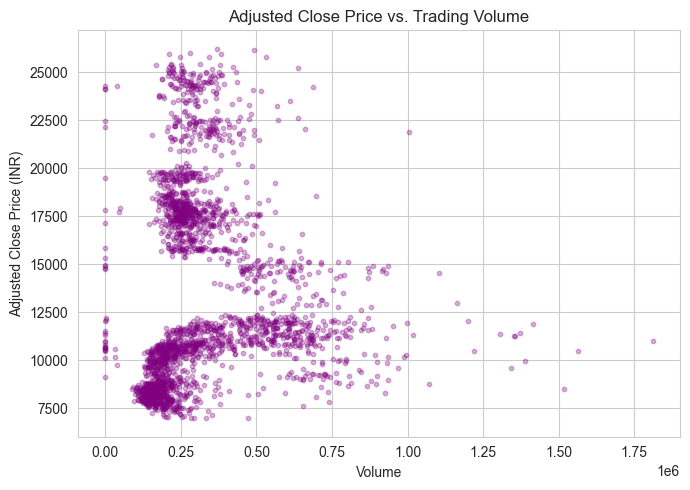

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Volume"], df["Adj Close"], alpha=0.3, s=10, color="purple")
plt.title("Adjusted Close Price vs. Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Adjusted Close Price (INR)")
plt.tight_layout()
plt.show()


**How to interpret this:** Each dot is one trading day. If you see **no clear pattern/cloud shape**, that tells us price *level* and volume aren't strongly related in a simple linear way — which is actually expected! A stock's absolute price level (₹8,000 vs ₹24,000) is driven by long-term growth, while volume is driven by day-to-day trading activity — two largely independent things. This is a good example of EDA teaching us what *isn't* related, which is just as valuable as finding what is.


### Correlation Matrix and Heatmap

**Why compute correlation for all columns at once?** A correlation matrix summarizes the *linear relationship* between every pair of numeric columns in a single number between -1 and +1, so instead of drawing a scatter plot for every possible pair, we get the full picture at a glance.

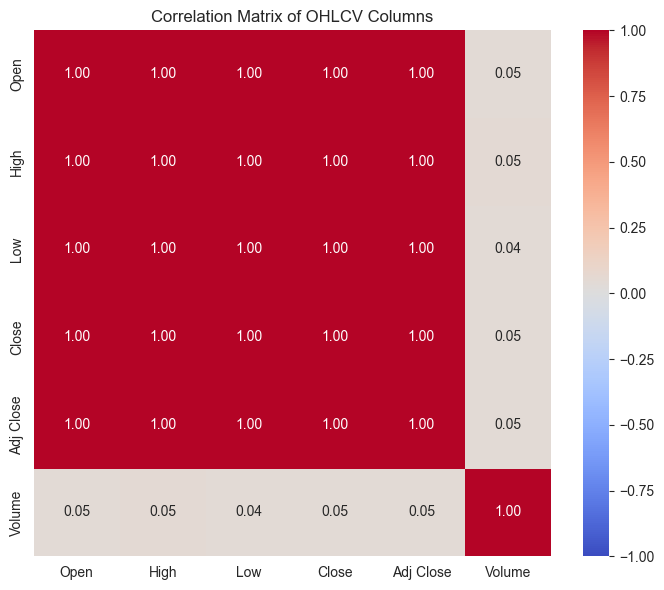

In [19]:
correlation_matrix = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of OHLCV Columns")
plt.tight_layout()
plt.show()


**Line by line:**
- `df[[...]].corr()` → computes the **Pearson correlation coefficient** for every pair of selected columns.
- `sns.heatmap(..., annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)` → draws the matrix as colored cells with the exact number printed inside each. Fixing `vmin=-1, vmax=1` ensures the color scale always means the same thing (dark red = +1, dark blue = -1) no matter what data we plot later.

**How to interpret this:**
- **Open, High, Low, Close, Adj Close will almost always show correlation very close to +1.00 with each other.** This isn't a mistake — on any given day, these four prices are naturally close together (a stock can't open at ₹100 and close at ₹10,000 in one normal day), so they move together almost perfectly.
- **Volume typically shows weak correlation (close to 0) with the price columns.** This confirms what we saw in the scatter plot above — raw price *level* and volume aren't strongly linearly related.

### Volume Analysis

Volume is one of our best available proxies for **liquidity** and **market participation** — central ideas in market microstructure. Let's look at how it evolves over time and its relationship to price *movement* (not price level).


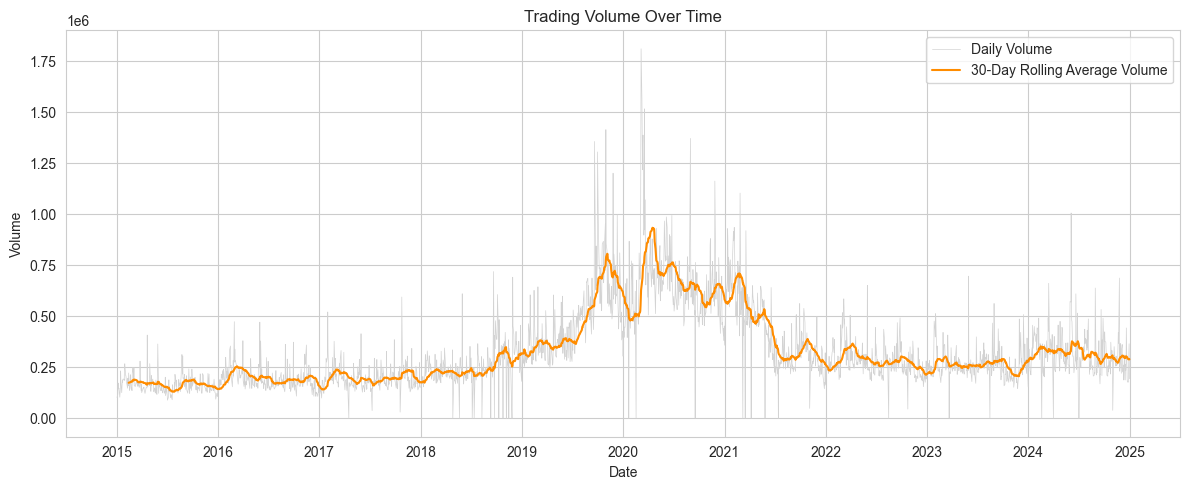

In [20]:
# A 30-day rolling average smooths out daily noise so we can see the underlying trend in trading activity
df["Volume_MA30"] = df["Volume"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Volume"], color="lightgray", linewidth=0.5, label="Daily Volume")
plt.plot(df.index, df["Volume_MA30"], color="darkorange", linewidth=1.5, label="30-Day Rolling Average Volume")
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.show()


# Quick preview: volume vs. the SIZE of that day's price change (not price level)

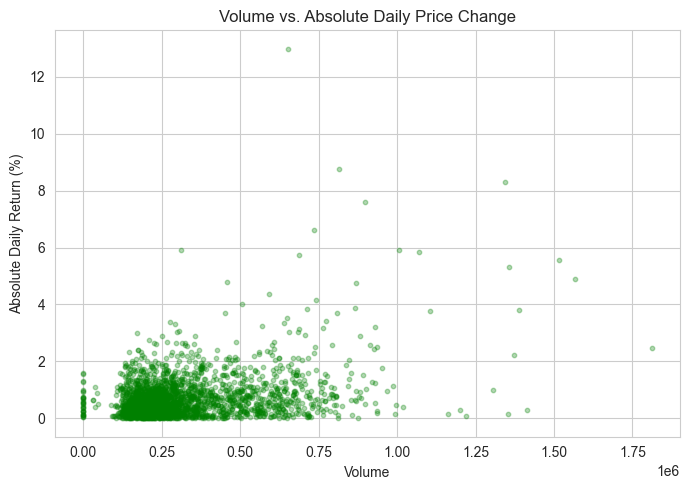

In [21]:
df["Daily_Return_pct"] = df["Adj Close"].pct_change() * 100

plt.figure(figsize=(7, 5))
plt.scatter(df["Volume"], df["Daily_Return_pct"].abs(), alpha=0.3, s=10, color="green")
plt.title("Volume vs. Absolute Daily Price Change")
plt.xlabel("Volume")
plt.ylabel("Absolute Daily Return (%)")
plt.tight_layout()
plt.show()


**How to interpret this:** Unlike the earlier price-*level*-vs-volume scatter plot, this one often shows a mild **upward-leaning cloud**: higher-volume days more often coincide with larger price swings (in either direction). This is the microstructure relationship we were originally looking for — it's the *rate of price change*, not the price level, that tends to track trading activity. We'll formalize and test this relationship statistically in Hypothesis Testing.






##  Exploratory Data Analysis — Part 3 (Final)

This is the final EDA milestone. We cover **Daily Return Analysis**, **Volatility Analysis**, and **Moving Average Analysis** — three concepts that are central to everything we'll build in Feature Engineering and Clustering next.



### Daily Return Analysis

**Why not just analyze raw price?** Raw price levels aren't directly comparable across time (₹8,000 in 2015 vs ₹24,000 in 2024 aren't on the same "scale"). **Returns** — the percentage change from one day to the next — put every day on the same, comparable scale, which is essential before we can meaningfully compare volatility or behavior across different years.


In [22]:
import numpy as np

# Daily return: simple percentage change from the previous day
df["Daily_Return"] = df["Adj Close"].pct_change()

# Log return: an alternative way of measuring the same thing
df["Log_Return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))

df[["Adj Close", "Daily_Return", "Log_Return"]].head() 


,Adj Close,Daily_Return,Log_Return
Date,,,
2015-01-02,8395.450195,NaN,NaN
2015-01-05,8378.400391,-0.002031,-0.002033
2015-01-06,8127.350098,-0.029964,-0.030422
2015-01-07,8102.100098,-0.003107,-0.003112
2015-01-08,8234.599609,0.016354,0.016221


**Line by line:**
- `df["Adj Close"].pct_change()` → for each day, computes `(today's price − yesterday's price) / yesterday's price`. The very first row becomes `NaN` since there's no "yesterday" to compare against — this is expected, not an error.
- `np.log(df["Adj Close"] / df["Adj Close"].shift(1))` → the **log return**, a very close approximation of the simple return for small day-to-day changes, but with a useful mathematical property: log returns over multiple days can simply be **added together** to get the total log return over that period (simple percentage returns cannot be added this way — they must be compounded). This matters once we start building rolling/aggregated features.



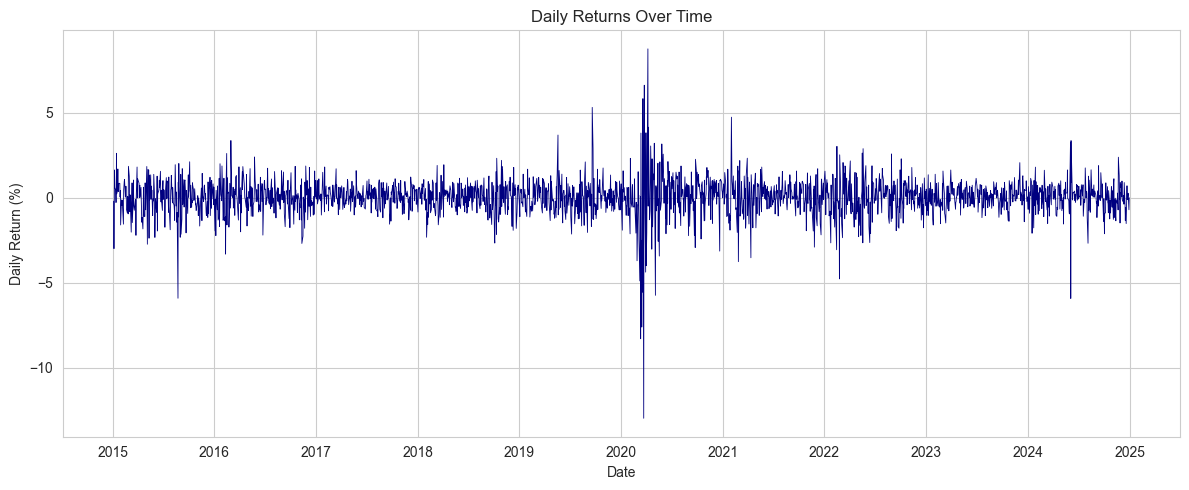

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Daily_Return"] * 100, color="navy", linewidth=0.6)
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.tight_layout()
plt.show()


**How to interpret this:** This is often called a **"volatility clustering"** view — notice that large swings (both up and down) tend to bunch together in certain periods, rather than being spread evenly across time. Calm periods look like a thin, flat band; turbulent periods (e.g. around major shocks) show a visibly "thicker," spikier band. This pattern — calm and turbulent periods clustering together — is one of the most well-documented facts in real financial markets, and it's exactly the kind of pattern our later clustering step will try to capture automatically.


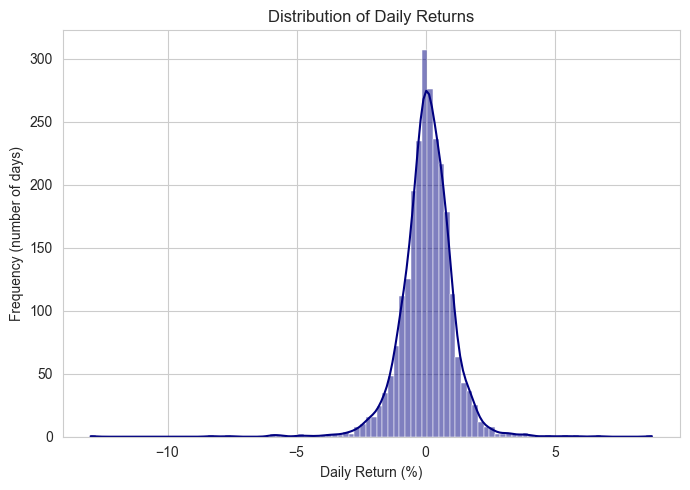

In [24]:
plt.figure(figsize=(7, 5))
sns.histplot(df["Daily_Return"].dropna() * 100, kde=True, color="navy")
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency (number of days)")
plt.tight_layout()
plt.show()


**How to interpret this:** Real stock returns are almost always centered near 0% (most days are unremarkable) but have **"fat tails"** — extreme up/down days happen more often than a perfect bell curve (Normal distribution) would predict. Beginners often assume returns are perfectly Normal; in reality, this "fat tail" behavior is *why* risk in financial markets is often larger than naive models expect. We'll test this more formally in (Hypothesis Testing).

### Volatility Analysis

**Why do we need a separate volatility measure at all, if we already have returns?** A single day's return tells us what happened *that day*. Volatility tells us how *unpredictable/turbulent* a stretch of time has been overall — this is usually measured as the **standard deviation of returns over a rolling window** (e.g., the last 21 trading days ≈ 1 trading month).


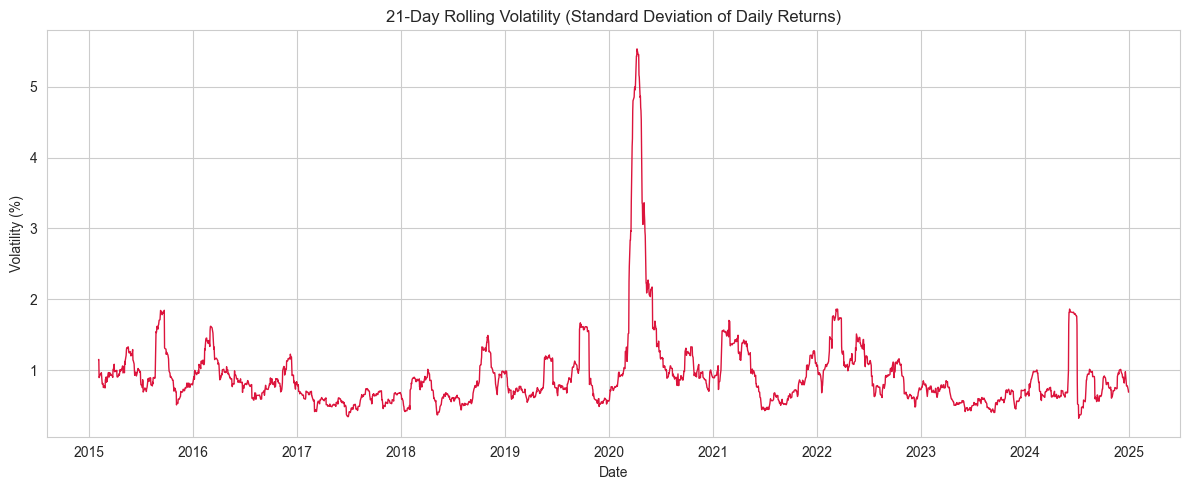

In [25]:
# Rolling volatility: standard deviation of daily returns over a 21-trading-day window
df["Volatility_21d"] = df["Daily_Return"].rolling(window=21).std() * 100

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Volatility_21d"], color="crimson", linewidth=1)
plt.title("21-Day Rolling Volatility (Standard Deviation of Daily Returns)")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.tight_layout()
plt.show()



**How to interpret this chart:** High spikes indicate stretches where the market was unusually turbulent day-to-day; flatter, low stretches indicate calmer periods. Notice how this lines up with the "thick bands" we spotted in the daily returns chart above — this rolling volatility measure is essentially quantifying that visual pattern into a single number per day, which we'll use directly as a **feature** for clustering .

### Moving Average Analysis

**Why moving averages?** A moving average (MA) smooths out day-to-day noise in the price itself, making the underlying **trend** easier to see — similar to what we did with volume ahed.


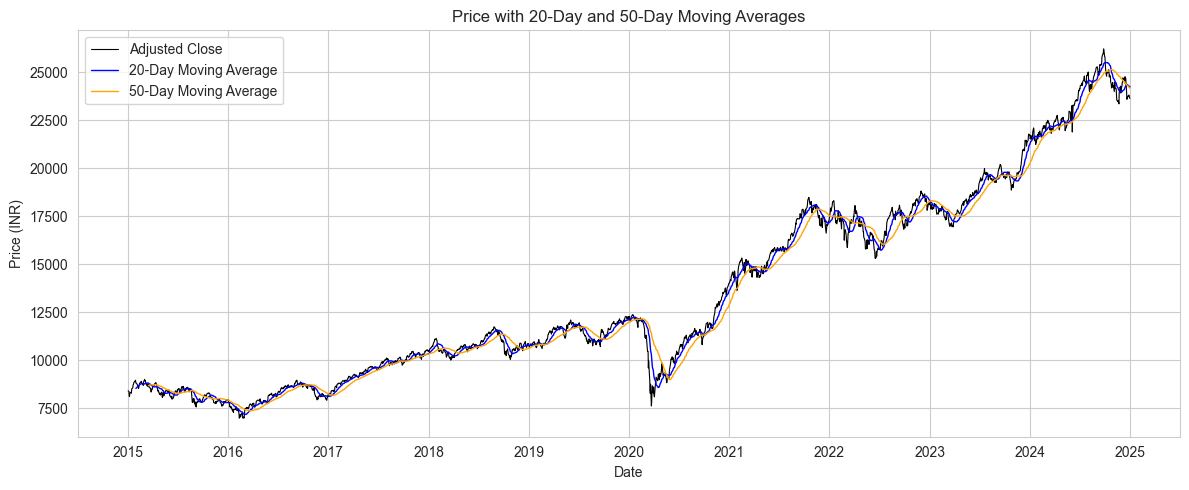

In [26]:
df["MA20"] = df["Adj Close"].rolling(window=20).mean()
df["MA50"] = df["Adj Close"].rolling(window=50).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"], label="Adjusted Close", color="black", linewidth=0.8)
plt.plot(df.index, df["MA20"], label="20-Day Moving Average", color="blue", linewidth=1)
plt.plot(df.index, df["MA50"], label="50-Day Moving Average", color="orange", linewidth=1)
plt.title("Price with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.tight_layout()
plt.show()


**How to interpret this:**
- The **20-day MA** (shorter window) hugs the actual price more closely and reacts faster to recent changes.
- The **50-day MA** (longer window) is smoother and reacts more slowly, representing a longer-term trend.
- When the shorter MA crosses **above** the longer MA, it's often called a **"golden cross"** (commonly associated with a shift toward an uptrend); crossing **below** is a **"death cross"** (associated with a shift toward a downtrend). We mention these terms since you'll encounter them in finance contexts, but we are **not** using them as trading signals here — our goal is describing behavior, not generating buy/sell calls.




## Feature Engineering 

**Why feature engineering matters here specifically:** Our upcoming Clustering step needs to group *days* into "market regimes" (e.g. calm vs. turbulent). But KMeans and Hierarchical Clustering can't work directly on raw prices — they need **numeric descriptors of behavior** for each day. That's exactly what this step builds: turning raw OHLCV rows into a table of meaningful behavioral features.

### Feature 1 & 2: Daily Return and Log Return (recap)
 These describe **how much the price moved** on a given day, on a comparable percentage scale. This is our most fundamental "behavior" feature.

### Feature 3: Price Range

**What it captures:** How much a price "haggled" within a single day — a simple, direct proxy for that day's volatility, independent of the multi-day rolling calculations we've used so far.


In [27]:
df["Price_Range"] = df["High"] - df["Low"]

# Also express it as a PERCENTAGE of price, so it's comparable across years
# (a ₹100 range means something very different when the index is at 8,000 vs 24,000)
df["Price_Range_Pct"] = (df["High"] - df["Low"]) / df["Close"] * 100

df[["High", "Low", "Close", "Price_Range", "Price_Range_Pct"]].head()


,High,Low,Close,Price_Range,Price_Range_Pct
Date,,,,,
2015-01-02,8410.599609,8288.700195,8395.450195,121.899414,1.451970
2015-01-05,8445.599609,8363.900391,8378.400391,81.699219,0.975117
2015-01-06,8327.849609,8111.350098,8127.350098,216.499512,2.663839
2015-01-07,8151.200195,8065.450195,8102.100098,85.750000,1.058368
2015-01-08,8243.500000,8167.299805,8234.599609,76.200195,0.925366


**Why compute a percentage version too?** Comparing an absolute ₹ range across a decade is misleading, since the index itself has grown enormously — a ₹100 range was huge in 2015 but tiny by 2024. Expressing it as a **percentage of that day's price** puts every day on the same scale, exactly like we did with returns.

### Rolling Mean and Rolling Std of Price

**Why do we need rolling mean/std of the *price itself*, separate from the volatility-of-returns we already built?** Rolling mean of price is essentially what our Moving Averages already are (MA20 = 20-day rolling mean of price) — it captures **trend**. Rolling standard deviation of the *price* (not returns) captures how much the price level itself has been fluctuating around that trend recently — a slightly different signal than return-volatility, useful for clustering to pick up on.


In [28]:
df["Rolling_Mean_20"] = df["Adj Close"].rolling(window=20).mean()
df["Rolling_Std_20"] = df["Adj Close"].rolling(window=20).std()

df[["Adj Close", "Rolling_Mean_20", "Rolling_Std_20"]].tail()


,Adj Close,Rolling_Mean_20,Rolling_Std_20
Date,,,
2024-12-24,23727.650391,24315.912598,365.202940
2024-12-26,23750.199219,24289.677539,386.528042
2024-12-27,23813.400391,24284.640039,392.293283
2024-12-30,23644.900391,24260.330078,416.619165
2024-12-31,23644.800781,24228.767578,438.692099


### Volatility (recap) and Moving Averages (recap)

We already have `Volatility_21d` (rolling std of *returns*) and `MA20` / `MA50` (rolling mean of *price*)  no need to recompute these, they'll carry through since we're working with the same `df`.

### Feature 7: Lag Features

**What is a "lag feature" and why do we need it?** A lag feature is simply *yesterday's* (or n-days-ago's) value of some column, placed on *today's* row. This matters because market behavior often has short-term memory — today's volume or return can be related to what happened very recently. Without lag features, a clustering or ML model only ever sees "today" in isolation, with no sense of recent momentum.


In [29]:
# Lag features: yesterday's, 2-days-ago's, and 3-days-ago's return
for lag in [1, 2, 3]:
    df[f"Return_Lag{lag}"] = df["Daily_Return"].shift(lag)

# Yesterday's volume, since volume often has short-term momentum too
df["Volume_Lag1"] = df["Volume"].shift(1)

df[["Daily_Return", "Return_Lag1", "Return_Lag2", "Return_Lag3", "Volume", "Volume_Lag1"]].head(8)


,Daily_Return,Return_Lag1,Return_Lag2,Return_Lag3,Volume,Volume_Lag1
Date,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,101900,NaN
2015-01-05,-0.002031,NaN,NaN,NaN,118200,101900.0
2015-01-06,-0.029964,-0.002031,NaN,NaN,172800,118200.0
2015-01-07,-0.003107,-0.029964,-0.002031,NaN,164100,172800.0
2015-01-08,0.016354,-0.003107,-0.029964,-0.002031,143800,164100.0
2015-01-09,0.006060,0.016354,-0.003107,-0.029964,148000,143800.0
2015-01-12,0.004647,0.006060,0.016354,-0.003107,103200,148000.0
2015-01-13,-0.002835,0.004647,0.006060,0.016354,129600,103200.0


**Line by line:** `.shift(lag)` moves a column's values *forward* by `lag` rows — so the value that used to be on "3 days ago's" row now appears on "today's" row instead. This is exactly how we deliberately introduce "memory" of recent days into each row.


### Feature 8 (Optional): RSI — Relative Strength Index

**What is RSI, in plain language?** RSI is a classic indicator (0-100 scale) that measures whether recent price gains have been outpacing recent losses, or vice versa. Traditionally: RSI above 70 is described as "overbought" (recent gains have been unusually strong), and below 30 as "oversold" (recent losses have been unusually strong). We include it here purely as an additional **behavioral feature** for clustering — not as a trading signal.


In [30]:
# Standard 14-day RSI calculation
delta = df["Adj Close"].diff()
gain = delta.clip(lower=0)          # keep only positive price changes (0 elsewhere)
loss = -delta.clip(upper=0)         # keep only negative price changes, flipped positive (0 elsewhere)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

relative_strength = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + relative_strength))

df[["Adj Close", "RSI_14"]].tail()


,Adj Close,RSI_14
Date,,
2024-12-24,23727.650391,32.011432
2024-12-26,23750.199219,23.932179
2024-12-27,23813.400391,26.893892
2024-12-30,23644.900391,25.404024
2024-12-31,23644.800781,25.518065


**Line by line:**
- `delta = df["Adj Close"].diff()` → the raw day-to-day price change (similar to return, but in ₹ rather than %).
- `gain = delta.clip(lower=0)` → keeps only the "up" days' changes, replacing negative changes with 0.
- `loss = -delta.clip(upper=0)` → keeps only the "down" days' changes, flips them positive, replacing positive changes with 0.
- `avg_gain` / `avg_loss` → 14-day rolling averages of typical gains and losses.
- The final formula converts the ratio of average gain to average loss into the standard 0-100 RSI scale.

### Assembling the final feature set

Now we gather everything into a single, clean feature table — and importantly, **drop the rows with `NaN`** that rolling/lag/shift calculations naturally create at the start of the dataset (they simply don't have enough history yet to compute a 20 or 50-day window).


In [31]:
feature_columns = [
    "Daily_Return", "Log_Return",
    "Price_Range", "Price_Range_Pct",
    "Rolling_Mean_20", "Rolling_Std_20",
    "Volatility_21d", "MA20", "MA50",
    "Return_Lag1", "Return_Lag2", "Return_Lag3", "Volume_Lag1",
    "RSI_14",
]

features_df = df[feature_columns].dropna()

print("Feature set shape:", features_df.shape)
features_df.head()


Feature set shape: (2410, 14)


,Daily_Return,Log_Return,Price_Range,Price_Range_Pct,Rolling_Mean_20,Rolling_Std_20,Volatility_21d,MA20,MA50,Return_Lag1,Return_Lag2,Return_Lag3,Volume_Lag1,RSI_14
Date,,,,,,,,,,,,,,
2015-03-17,0.010442,0.010388,111.750000,1.281052,8799.122412,104.949267,0.954602,8799.122412,8669.166973,-0.001688,-0.014614,0.008741,163300.0,48.128324
2015-03-18,-0.004287,-0.004297,83.250000,0.958450,8792.949951,107.904750,0.926562,8792.949951,8674.975977,0.010442,-0.001688,-0.014614,177000.0,46.194163
2015-03-19,-0.005900,-0.005918,173.549805,2.009923,8781.227490,111.859152,0.933277,8781.227490,8680.100977,-0.004287,0.010442,-0.001688,156400.0,47.626889
2015-03-20,-0.007383,-0.007410,74.900391,0.873892,8765.007520,117.808983,0.926047,8765.007520,8688.971982,-0.005900,-0.004287,0.010442,163500.0,35.435297
2015-03-23,-0.002333,-0.002336,67.799805,0.792897,8750.872559,125.832223,0.920255,8750.872559,8697.947988,-0.007383,-0.005900,-0.004287,174600.0,26.054580


**Why `dropna()` here, and not earlier?** Earlier in Data Cleaning , we cleaned the *raw* OHLCV data. These new `NaN`s are different — they're an **expected side-effect** of rolling/lag calculations needing history, not a data quality problem. It's correct practice to build all features first, then drop the resulting incomplete rows only once, right before we hand the table to clustering/ML — which is exactly what we just did.



---
##  Hypothesis Testing 

We *visually* noticed that higher-volume days seemed to coincide with larger price swings. That was just an impression from a scatter plot — **hypothesis testing lets us check, with actual statistics, whether a pattern we see is likely to be real or could just be random noise.**

### What is a Null and Alternative Hypothesis?

Every hypothesis test starts with two competing claims:
- **Null Hypothesis (H₀):** "There is no real relationship/difference — anything we observed is just random chance." This is the assumption we test *against*.
- **Alternative Hypothesis (H₁):** "There IS a real relationship/difference." This is what we're trying to find evidence for.

We never *prove* H₁ is true — we only ask: "if H₀ were actually true, how surprising would our observed data be?" That "how surprising" is captured by the **p-value**. A common convention (which we'll use here) is: if p-value < 0.05, we say the result is "statistically significant" — meaning it's unlikely we'd see a pattern this strong purely by chance if H₀ were true.

### Test 1: T-test — Do high-volume days have larger price swings than low-volume days?

**H₀:** The average absolute daily return is the same for high-volume days and low-volume days.
**H₁:** The average absolute daily return is different between high-volume and low-volume days.

A **T-test** compares the means of two groups and tells us if the difference between them is statistically significant.


In [32]:
from scipy import stats

# We need the absolute size of the return (we care about magnitude of movement, not direction)
df["Abs_Return"] = df["Daily_Return"].abs()

# Split days into two groups using the median volume as a cutoff
median_volume = df["Volume"].median()
high_volume_days = df[df["Volume"] >= median_volume]["Abs_Return"].dropna()
low_volume_days = df[df["Volume"] < median_volume]["Abs_Return"].dropna()

t_stat, p_value = stats.ttest_ind(high_volume_days, low_volume_days, equal_var=False)

print(f"Mean absolute return (high volume days): {high_volume_days.mean():.5f}")
print(f"Mean absolute return (low volume days):  {low_volume_days.mean():.5f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Mean absolute return (high volume days): 0.00859
Mean absolute return (low volume days):  0.00560
T-statistic: 9.8025
P-value: 0.0000



- `df["Volume"].median()` → splits our data at the midpoint, giving two equally-sized groups (high vs. low volume days).
- `stats.ttest_ind(..., equal_var=False)` → runs an **independent two-sample T-test**. We use `equal_var=False` (known as Welch's T-test) rather than assuming both groups have identical variability — a safer default when we haven't specifically checked that assumption.

**Interpreting the result:** If `p_value < 0.05`, we **reject the null hypothesis** and conclude high-volume days do show a statistically significant difference in typical price-swing size compared to low-volume days. If `p_value >= 0.05`, we **fail to reject the null hypothesis** — meaning our data doesn't give strong enough evidence of a real difference (this does *not* prove there's no relationship, only that we don't have strong enough evidence for one).


### Test 2: ANOVA — Comparing more than two groups at once

A T-test only compares two groups. What if we want to compare **three or more** volume levels at once (e.g., Low / Medium / High)? For that we use **ANOVA (Analysis of Variance)**.

**H₀:** The average absolute return is the same across all volume tertile groups (Low, Medium, High).
**H₁:** At least one group's average absolute return is different from the others.



In [33]:
# Split volume into 3 equal-sized groups (tertiles)
df["Volume_Tertile"] = pd.qcut(df["Volume"], q=3, labels=["Low", "Medium", "High"])

low_group = df[df["Volume_Tertile"] == "Low"]["Abs_Return"].dropna()
medium_group = df[df["Volume_Tertile"] == "Medium"]["Abs_Return"].dropna()
high_group = df[df["Volume_Tertile"] == "High"]["Abs_Return"].dropna()

f_stat, p_value_anova = stats.f_oneway(low_group, medium_group, high_group)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4f}")


F-statistic: 65.0833
P-value: 0.0000



- `pd.qcut(df["Volume"], q=3, ...)` → divides the data into 3 groups with (approximately) equal *counts* of days in each — not equal ranges of volume. This is generally more useful than fixed cutoffs, since volume distributions are skewed.
- `stats.f_oneway(...)` → runs a **one-way ANOVA**, testing whether the means of all three groups are equal.

**Interpreting the result:** A significant p-value (< 0.05) tells us at least one volume-tertile group behaves differently from the others — but ANOVA alone doesn't say *which* group(s). If needed, a follow-up "post-hoc" test (like Tukey's HSD) could identify exactly which pairs differ — outside the scope of this project, but good to know exists.

### Test 3: Correlation Significance

We computed correlation values in a heatmap, but a raw correlation number alone doesn't tell us if it's statistically meaningful, especially with a small sample. `pearsonr` gives us **both** the correlation coefficient **and** a p-value testing whether that correlation is significantly different from zero.

**H₀:** The true correlation between Volume and Absolute Return is 0 (no linear relationship).
**H₁:** The true correlation is not 0.


In [34]:
clean_data = df[["Volume", "Abs_Return"]].dropna()

correlation, p_value_corr = stats.pearsonr(clean_data["Volume"], clean_data["Abs_Return"])

print(f"Correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value_corr:.4f}")


Correlation coefficient: 0.3236
P-value: 0.0000


**Interpreting the result:** With enough data (and stock market data usually gives us thousands of rows), even a fairly small correlation coefficient can be statistically significant — meaning it's very unlikely to be pure chance, even if it's not a huge, dramatic relationship in absolute terms. This is worth remembering: **statistical significance tells us a relationship is probably real; it does not tell us the relationship is large or important in practice.** Always report both the correlation number itself and the p-value together, never just one.


1. **Treating "p < 0.05" as proof of truth.** A significant result means the data is *unlikely* under the null hypothesis — it's evidence, not certainty. There's always some chance of a "false positive."
2. **Confusing statistical significance with practical importance.** A correlation of 0.05 can be "significant" with enough data but may be far too weak to matter for any real decision.
3. **Running many tests and only reporting the "significant" ones** ("p-hacking"). If you test enough relationships, some will look significant by chance alone — always report what you tested, not just what "worked."
4. **Forgetting that correlation/significance never implies causation.** Even a strong, significant Volume-vs-Return relationship doesn't tell us volume *causes* bigger price swings (or vice versa) — both could stem from a shared cause, like breaking news.


---
##  Clustering — Part 1: KMeans 

This is one of the core deliverables of the whole project. 

- **Part 1 :** Feature scaling + KMeans clustering (Elbow Method, Silhouette Score, fitting, interpretation)
- **Part 2 :** Hierarchical Clustering with a dendrogram, and comparing it to KMeans

### Why clustering, and why here specifically?

So far, every step has looked at data we already understood (returns, volatility, etc.) using **labels we already know** (like "before/after a date" or "high/low volume"). Clustering is different — it's **unsupervised learning**: we give the algorithm our feature table with *no labels at all*, and ask it to find natural groupings on its own. If it finds, say, 3 clear groups of days that share similar volatility/return/RSI patterns, we can interpret those groups as distinct **"market regimes"** — e.g. "calm/trending", "high-volatility/turbulent", "low-volume/quiet" — purely from the data's own structure, not from rules we imposed.

### Step A: Feature Scaling

**Why is this required before clustering (and not optional)?** KMeans and Hierarchical Clustering both group points based on **distance** between them. Our features are on wildly different scales — `Return_Lag1` is a small decimal (~0.01), while `MA20` is in the thousands. Without scaling, the distance calculation would be almost entirely dominated by whichever feature happens to have the largest raw numbers (here, price-based features), making the clustering essentially ignore return/RSI-based features altogether — even though they may be just as behaviorally important.


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

print("Scaled feature shape:", scaled_features.shape)
print("Mean of each scaled column (should be ~0):", scaled_features.mean(axis=0).round(2))
print("Std of each scaled column (should be ~1):", scaled_features.std(axis=0).round(2))


Scaled feature shape: (2410, 14)
Mean of each scaled column (should be ~0): [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.  0.]
Std of each scaled column (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



- `StandardScaler()` → transforms each column so it has **mean 0 and standard deviation 1**. This puts every feature on the same footing, regardless of its original units or scale.
- `scaler.fit_transform(features_df)` → `fit` learns each column's mean/std from our data, and `transform` applies the scaling. We use `fit_transform` together since this is the only dataset we have (no separate train/test split needed for clustering, since it's unsupervised).

### Step B: Choosing K — The Elbow Method

**The core question:** how many clusters (K) should we ask KMeans to find? There's no single "correct" answer — the Elbow Method gives us a data-driven starting point.

**How it works:** We run KMeans for a range of K values and record the **inertia** (sum of squared distances from each point to its assigned cluster center — lower is "tighter" clusters). Inertia always decreases as K increases (more clusters can always fit the data more tightly), but the *rate* of improvement typically slows down sharply after some point — that "elbow" or bend in the curve is a good candidate for K.


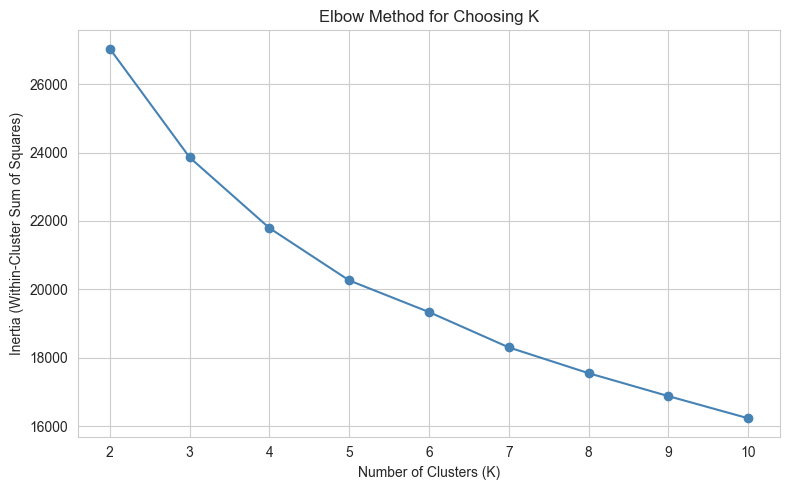

In [36]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(scaled_features)
    inertias.append(kmeans_model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker="o", color="steelblue")
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()



- `random_state=42` → makes KMeans' results reproducible. KMeans starts from random initial cluster centers, so without fixing this seed, you'd get slightly different clusters each time you rerun the cell.
- `n_init=10` → runs KMeans 10 times with different random starting points and keeps the best result, since KMeans can occasionally get "stuck" in a suboptimal grouping depending on where it starts.
- `kmeans_model.inertia_` → the metric described above; we collect one value per K to plot the elbow curve.

**How to read this chart:** Look for the point where the curve stops dropping sharply and starts to flatten out — that "bend" suggests adding more clusters beyond that point gives diminishing returns. This is a visual, somewhat subjective judgment call, which is exactly why we pair it with a second, more objective method next.

### Step C: Choosing K — Silhouette Score

**Why not rely on the Elbow Method alone?** The "elbow" can sometimes be ambiguous or hard to pinpoint exactly. The **Silhouette Score** gives a more precise, numeric answer: for each point, it measures how similar it is to its own cluster compared to the next-nearest cluster, averaged across all points. It ranges from -1 to +1 — higher is better (well-separated, well-matched clusters).


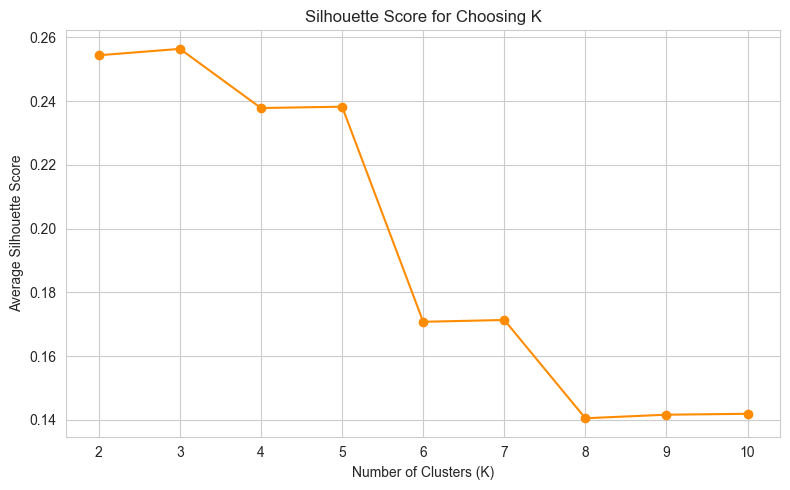

In [37]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), silhouette_scores, marker="o", color="darkorange")
plt.title("Silhouette Score for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


**How to read this chart:** Pick the K with the **highest** silhouette score — that represents the clustering configuration where points fit most cleanly into their assigned group versus neighboring groups. In market regime detection, it's common (and perfectly fine) for the best score to be at a small K like 2 or 3 — markets often separate most cleanly into a small number of broad regimes (e.g., "calm" vs. "turbulent") rather than many finely-grained ones.

 **Choosing the final K:** Use the Elbow Method for a rough starting range, then use the Silhouette Score to pick the best specific value within that range. For this notebook, inspect both charts above and set `OPTIMAL_K` below to whatever value makes sense for your actual downloaded data (we can't hardcode this in advance since the "best" K depends on your specific dataset).

### Step D: Fitting Final KMeans Model and Interpreting Clusters


In [38]:
OPTIMAL_K = 3  

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
features_df["Cluster_KMeans"] = final_kmeans.fit_predict(scaled_features)

cluster_profile = features_df.groupby("Cluster_KMeans").mean().round(4)
cluster_profile


,Daily_Return,Log_Return,Price_Range,Price_Range_Pct,Rolling_Mean_20,Rolling_Std_20,Volatility_21d,MA20,MA50,Return_Lag1,Return_Lag2,Return_Lag3,Volume_Lag1,RSI_14
Cluster_KMeans,,,,,,,,,,,,,,
0,0.0009,0.0009,101.0068,1.0179,9979.0151,149.2929,0.8405,9979.0151,9897.5817,0.0007,0.0007,0.0005,308568.7045,55.2976
1,-0.0084,-0.0090,388.4242,3.5658,11496.4833,489.7289,2.4884,11496.4833,11915.1824,-0.0045,-0.0055,-0.0032,706472.6316,43.7066
2,0.0008,0.0007,191.7171,1.0214,18958.8630,286.1575,0.8400,18958.8630,18789.1380,0.0006,0.0008,0.0008,311219.5537,57.0774


 `groupby("Cluster_KMeans").mean()` The cluster numbers (0, 1, 2, ...) themselves are meaningless labels — KMeans doesn't know or care what "regime" means. To actually interpret what each cluster *represents*, we look at the average feature values within each group. For example:
- A cluster with high `Volatility_21d`, high `Price_Range_Pct`, and RSI far from 50 → likely a **"turbulent/high-volatility"** regime.
- A cluster with low `Volatility_21d`, small `Price_Range_Pct`, and RSI near 50 → likely a **"calm/stable"** regime.
- A cluster with a strongly rising `Rolling_Mean_20`/`MA20` relative to others → possibly a **"trending/bullish"** regime.

The specific number of clusters and their character depends entirely on your chosen stock/index and time period.


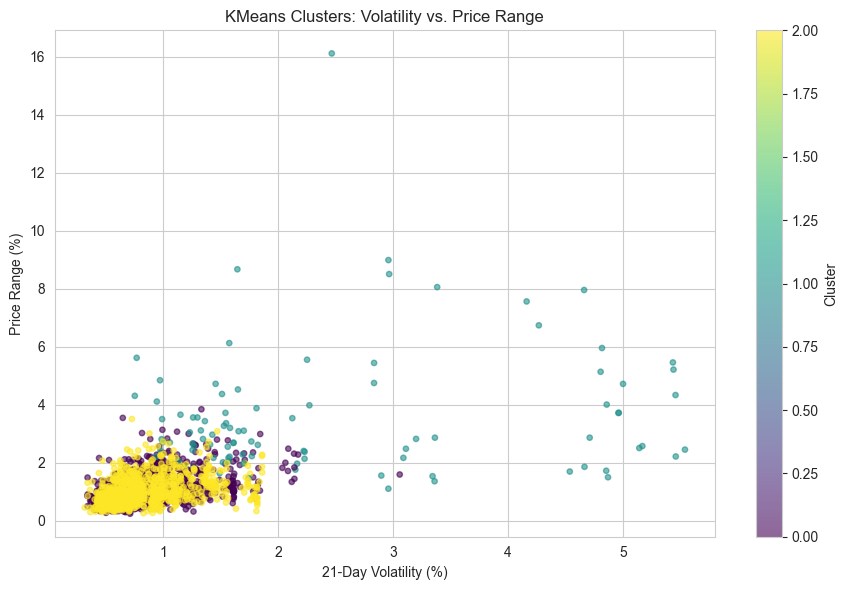

In [39]:
# Visualize clusters using two of our most interpretable features
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    features_df["Volatility_21d"],
    features_df["Price_Range_Pct"],
    c=features_df["Cluster_KMeans"],
    cmap="viridis",
    alpha=0.6,
    s=15,
)
plt.title("KMeans Clusters: Volatility vs. Price Range")
plt.xlabel("21-Day Volatility (%)")
plt.ylabel("Price Range (%)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


Each color represents a distinct cluster. If clusters form visibly separate "blobs" along these two axes, that's a good sign the clustering has found a genuine, interpretable structure related to market turbulence. If the colors are heavily mixed with no visible separation on *these two specific features*, it just means these two features alone don't fully explain the clustering — remember, KMeans used **all 14 scaled features**, not just these two, so some cluster structure may only be visible in combinations of features we aren't plotting here.

1. **Skipping feature scaling.** As explained above, this silently makes clustering ignore smaller-scale features entirely.
2. **Picking K purely by "eyeballing" the elbow chart without checking the Silhouette Score too.** Using both together gives a much more defensible choice than either alone.
3. **Forgetting `random_state`, and then panicking when clusters "change" on rerun.** KMeans has randomness in its starting points — fixing the seed makes results reproducible and comparable across runs.
4. **Assigning a definitive real-world label (like "crash regime") to a cluster based on gut feeling alone**, without actually checking the cluster's average feature values first via `groupby().mean()`.
5. **Expecting clusters to align perfectly with calendar time periods (e.g., "cluster 0 = 2020").** Clusters group *similar-behaving days*, which can be scattered throughout the whole time range — not necessarily one continuous block of time.


---
##  Part 2: Hierarchical Clustering 

### Why try a second clustering method at all?

KMeans forces a specific number of clusters upfront and assumes clusters are roughly round "blobs" in feature space. **Hierarchical Clustering** takes a different approach: it builds a tree of nested groupings from the bottom up, merging the two most similar days first, then progressively merging clusters of clusters, all the way up to one giant cluster. This is useful because:
- It doesn't force us to commit to K before we start.
- The resulting **dendrogram** (tree diagram) lets us *see* the merging structure and choose K by inspection, as a visual complement to the Elbow/Silhouette numbers from Part 1.
- If KMeans and Hierarchical Clustering broadly agree on groupings, that's reassuring evidence the clusters reflect real structure — not just an artifact of one particular algorithm.

### Building and Visualizing the Dendrogram


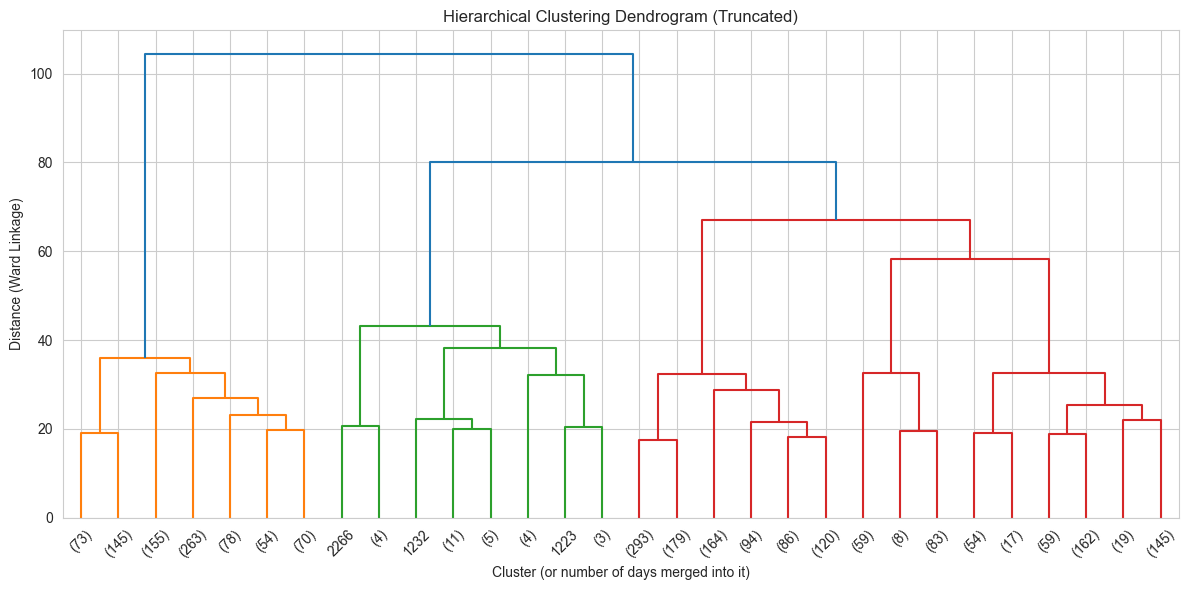

In [40]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Ward linkage minimizes the increase in within-cluster variance at each merge step,
# which tends to produce compact, evenly-sized clusters -- a good general-purpose default.
linkage_matrix = linkage(scaled_features, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",   # only show the last p merged clusters, to keep the plot readable
    p=30,
    show_leaf_counts=True,
)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Cluster (or number of days merged into it)")
plt.ylabel("Distance (Ward Linkage)")
plt.tight_layout()
plt.show()



- `linkage(scaled_features, method="ward")` → computes the full merge history: which two points/clusters merge first, second, etc., and at what "distance" (dissimilarity) each merge happens.
- `truncate_mode="lastp", p=30` → with thousands of trading days, a full dendrogram would have thousands of tangled leaf branches and be unreadable. Truncating to the last 30 merges keeps the plot interpretable while still showing the overall structure.

**How to read a dendrogram:**
- Each vertical line represents a merge between two clusters; the **height** at which two branches join represents how *dissimilar* those two groups were when merged.
- **Long vertical lines before a merge** indicate the two groups being joined were quite different from each other — a natural place to "cut" the tree into separate clusters.
- To choose K visually: imagine drawing a horizontal line across the dendrogram — the number of vertical lines it crosses is the number of clusters at that "cut height." Choosing a cut just below a particularly tall merge (a big jump in height) is a common rule of thumb, similar in spirit to the Elbow Method.

### Fitting Agglomerative Clustering

Now we fit the actual clustering model using the same K we chose for KMeans (for a fair, direct comparison), via scikit-learn's `AgglomerativeClustering`.


In [41]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
features_df["Cluster_Hierarchical"] = hierarchical_model.fit_predict(scaled_features)

features_df["Cluster_Hierarchical"].value_counts().sort_index()


Cluster_Hierarchical
0    1542
1     838
2      30
Name: count, dtype: int64

**Why use `OPTIMAL_K` (the same K chosen for KMeans) here?** This lets us directly compare whether two *different* clustering algorithms, run on the *same* features, agree on how days should be grouped — a useful sanity check on whether our earlier KMeans clusters reflect genuine structure.

### Comparing KMeans and Hierarchical Clustering


In [42]:
comparison_table = pd.crosstab(
    features_df["Cluster_KMeans"],
    features_df["Cluster_Hierarchical"],
    rownames=["KMeans Cluster"],
    colnames=["Hierarchical Cluster"],
)
comparison_table


Hierarchical Cluster,0,1,2
KMeans Cluster,,,
0,1358,16,0
1,61,4,30
2,123,818,0


 Each cell shows how many days fall into a given (KMeans cluster, Hierarchical cluster) combination. If the two methods agree strongly, you'll see most of the counts concentrated in a clear diagonal-ish pattern (each KMeans cluster mapping mostly onto one Hierarchical cluster). If the counts are spread out fairly evenly across every cell, the two methods are finding quite different structure — which would be worth investigating (e.g., by trying a different K, or a different linkage method) rather than trusting either blindly.


In [43]:
# Profile the hierarchical clusters the same way we profiled KMeans clusters
hierarchical_profile = features_df.groupby("Cluster_Hierarchical")[feature_columns].mean().round(4)
hierarchical_profile


,Daily_Return,Log_Return,Price_Range,Price_Range_Pct,Rolling_Mean_20,Rolling_Std_20,Volatility_21d,MA20,MA50,Return_Lag1,Return_Lag2,Return_Lag3,Volume_Lag1,RSI_14
Cluster_Hierarchical,,,,,,,,,,,,,,
0,0.0001,0.0000,123.7325,1.1330,10602.3176,167.7501,0.8903,10602.3176,10513.6472,0.0003,0.0004,0.0006,334640.6615,55.0065
1,0.0014,0.0013,180.0185,0.9544,19087.6516,282.2175,0.8121,19087.6516,18927.8530,0.0009,0.0008,0.0004,290075.6563,57.0821
2,-0.0050,-0.0061,481.2767,5.0538,9979.9004,858.5938,4.2804,9979.9004,11273.7866,-0.0012,-0.0054,-0.0063,828220.0000,39.5384


As with KMeans, interpret this table by looking for which features stand out as unusually high or low in each cluster relative to the others (e.g., high `Volatility_21d` + high `Price_Range_Pct` → a turbulent regime).


1. **Trying to plot the full, untruncated dendrogram on thousands of data points.** It becomes an unreadable dense wall of lines — always truncate for large datasets.
2. **Assuming Hierarchical Clustering will always match KMeans exactly.** They use fundamentally different logic (centroid-based vs. tree-based merging), so some disagreement is normal and expected, especially for points near cluster boundaries — total agreement isn't the goal, general agreement on overall structure is what we're checking for.
3. **Not considering computational cost.** Hierarchical clustering's `linkage()` step has roughly quadratic time/memory complexity in the number of rows — fine for a few thousand daily rows like ours, but this approach would need modification (e.g., sampling) for tick-level or very large datasets.
4. **Picking a different linkage method (e.g., `single`, `complete`, `average`) without understanding it changes results.** `ward` (used here) tends to produce balanced, compact clusters and is a sensible default for this kind of continuous, scaled feature data — but it's worth knowing the choice is a modeling decision, not a fixed rule.


---
##  Supervised Learning for Market Regime Labeling 

### What are we actually testing here? 

This step is **not** about predicting *future* market regimes — that would require a very different, more careful setup (predicting *tomorrow's* regime from *today's* features). :

> **"Do our engineered features cleanly separate the market regimes that clustering found, or is the clustering structure fuzzy and inconsistent?"**

We do this by training a classifier to predict a day's **already-assigned cluster label**  using that same day's features. If a simple classifier can do this with high accuracy, it validates that our clusters correspond to genuinely distinguishable, well-defined patterns in the feature space — not arbitrary or overlapping groupings. This is a common, legitimate way to sanity-check unsupervised clustering results using supervised learning.

### Preparing the data

We use `Cluster_KMeans` as our target label `y`, and our scaled features as `X`.


In [44]:
from sklearn.model_selection import train_test_split

X = scaled_features
y = features_df["Cluster_KMeans"]

# shuffle=False keeps the data in chronological order when splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 1928
Test set size: 482


**Why `shuffle=False` (chronological split) instead of a random split?** This is an important, easy-to-miss detail with **any** time-series data. A random shuffle could put a day from 2016 in the test set while its immediate neighboring days (2016, same week) sit in the training set — the model could then implicitly "cheat" using information leaking across nearly-identical adjacent days. Splitting chronologically (train on the earlier ~80% of days, test on the most recent ~20%) better respects the fact that this is time-ordered data, avoiding a subtle form of the same lookahead-bias problem we've flagged since Data Cleaning.

### Training two simple classifiers

We'll try **Logistic Regression** (a simple linear model, easy to interpret) and a **Decision Tree** (captures non-linear boundaries, and directly tells us which features mattered most).


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression: a simple, interpretable linear classifier
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)
log_reg_accuracy = log_reg_model.score(X_test, y_test)

# Decision Tree: captures non-linear patterns, and gives us feature importances
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_accuracy = tree_model.score(X_test, y_test)

print(f"Logistic Regression test accuracy: {log_reg_accuracy:.4f}")
print(f"Decision Tree test accuracy:       {tree_accuracy:.4f}")


Logistic Regression test accuracy: 1.0000
Decision Tree test accuracy:       0.9959



- `max_iter=1000` (Logistic Regression) → gives the optimizer enough iterations to converge; the default (100) can sometimes be too low and trigger a convergence warning.
- `max_depth=4` (Decision Tree) → deliberately limits how deep the tree can grow. An unrestricted tree can perfectly memorize the training data (overfitting) — capping the depth keeps the tree simple and more likely to generalize, and also makes it easier for a human to interpret.
- `.score(X_test, y_test)` → returns accuracy (fraction of correct predictions) on the held-out test set — data the model never saw during training.

**What to expect:** Because the cluster labels were *derived from* these same features (via KMeans distance to centroids), a well-fit classifier often achieves **very high accuracy** here — sometimes close to 100%. This isn't a bug or "too good to be true" in a suspicious way — it's expected, and it's actually the *point*: high accuracy here means our clusters have clean, learnable boundaries in feature space, which supports treating them as meaningful, consistent regimes rather than arbitrary or noisy groupings.

### Which features matter most for defining a regime?


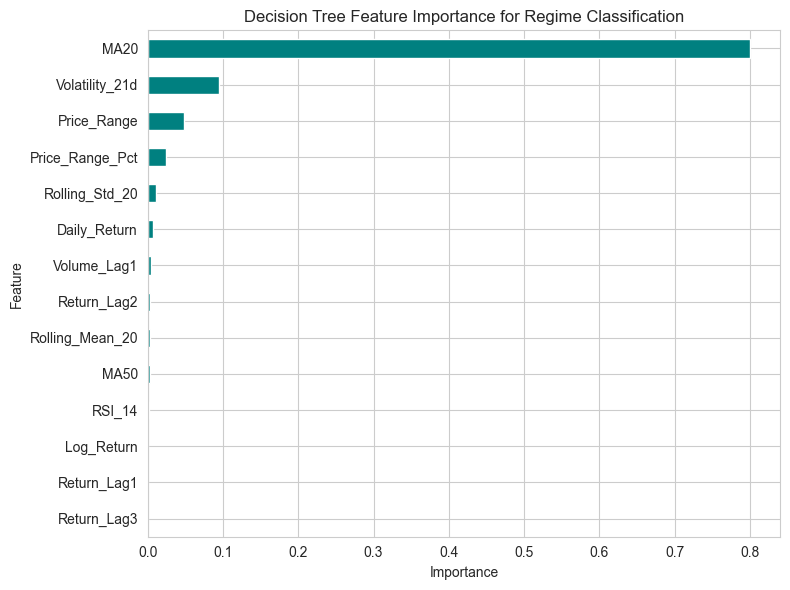

In [46]:
feature_importance = pd.Series(
    tree_model.feature_importances_, index=feature_columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feature_importance.plot(kind="barh", color="teal")
plt.title("Decision Tree Feature Importance for Regime Classification")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**How to interpret this:** The features with the highest importance are the ones the Decision Tree relied on most to distinguish between regimes — often trend-related features (like `MA20`) and volatility/return-related features dominate, since those are usually what most clearly separates "calm" from "turbulent" days. This gives a data-driven answer to "what actually defines a regime here?", rather than us guessing.

1. **Misinterpreting high accuracy as "the model predicts the future."** This model classifies *known, already-computed* labels from *same-day* features — it is a structure-validation exercise, not a forecasting model. A true forecasting version would need to predict *tomorrow's* regime using only *today's* (or earlier) information, and would likely perform far worse — an important distinction to state clearly in your project write-up.
2. **Using a random train/test split on time-series data.** As explained above, this can leak information between adjacent days and inflate performance unrealistically.
3. **Growing an unrestricted Decision Tree.** Without `max_depth`, trees can perfectly memorize training data, giving misleadingly perfect training accuracy while performing much worse on new data.
4. **Treating this step as mandatory validation of your clusters.** our project brief marks this step optional — reasonably strong clustering can already stand on its own (via Silhouette Score and interpretable cluster profiles); this classifier is a nice-to-have additional sanity check, not a requirement for your clusters to be considered valid.


---
## Model Evaluation

We've already evaluated our **clustering** (unsupervised) using the **Silhouette Score**  — that's the right evaluation tool for clustering, since there are no "correct answers" to compare against. Now we go deeper on evaluating our **classifier** from supervised, where we *do* have true labels to check against.

### Confusion Matrix

**What it shows:** A table comparing what the model *predicted* against what the true cluster label actually *was*, for every day in the test set. It's the foundation every other classification metric is built from.


<Figure size 600x500 with 0 Axes>

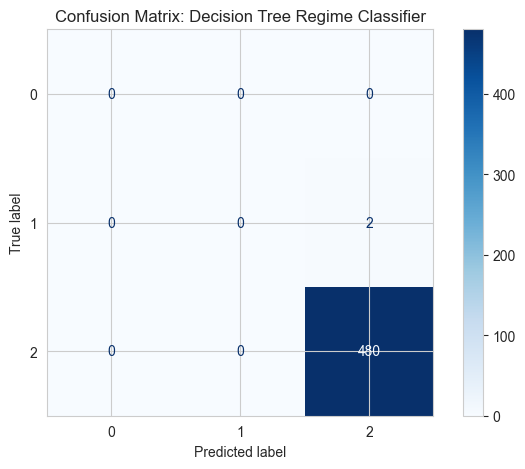

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = tree_model.predict(X_test)

all_labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=all_labels)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Decision Tree Regime Classifier")
plt.tight_layout()
plt.show()


**How to read it:** Rows represent the *true* cluster, columns represent the *predicted* cluster. Values on the **diagonal** are correct predictions; anything **off-diagonal** is a mistake — specifically, it tells you *which* regime the model confused with *which other* regime, which is far more informative than a single accuracy number alone.

>  **Important limitation to expect:** because we used a **chronological** train/test split (Milestone 12), and price-trend features like `MA20` heavily influence cluster assignment, it's common for the most recent ~20% of days (our test set) to fall almost entirely into *one* regime — especially over a strongly trending multi-year period. If your confusion matrix looks nearly one-dimensional (test data all from a single true class), that's not a bug in your code — it's a genuine characteristic of how regimes and time interact in this dataset.

### Precision, Recall, F1-Score

**Why do we need more than accuracy?** Accuracy alone can be misleading when classes are imbalanced (e.g., if 90% of days belong to one regime, a model that *always* predicts that regime gets 90% accuracy while being completely useless). These three metrics look at performance **per class**, which accuracy hides:

- **Precision:** Of all the days the model *predicted* as Regime X, what fraction actually *were* Regime X? (Measures false alarms.)
- **Recall:** Of all the days that *truly were* Regime X, what fraction did the model correctly catch? (Measures missed cases.)
- **F1-Score:** The harmonic mean of precision and recall — a single number balancing both, useful when you care about both false alarms and missed cases roughly equally.


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, labels=all_labels, zero_division=0))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         2
           2       1.00      1.00      1.00       480

    accuracy                           1.00       482
   macro avg       0.33      0.33      0.33       482
weighted avg       0.99      1.00      0.99       482



`Model_Evaluation_report` computes precision, recall, and F1 for every class individually, plus two useful averages:
- **macro avg** → treats every class equally, regardless of how many days fall into it. Useful when you care about performance on rare regimes just as much as common ones.
- **weighted avg** → weights each class by how many days it has. Closer to overall accuracy, but still broken down per-metric.
- `zero_division=0` → if a class happens to have zero predicted or true instances in the test set (as flagged in the limitation note above), this avoids a distracting warning and just reports 0 for that undefined metric.

**How to choose which metric matters most for this project:** Since we're doing *descriptive* regime analysis rather than a decision system with real financial stakes (e.g., no false-alarm cost like a fraud detector would have), **balanced performance across all regimes (macro avg F1)** is generally the most meaningful single summary metric here — it won't be dominated by whichever regime happens to have the most days.


1. **Reporting only accuracy and stopping there.** As shown above, accuracy can look great while hiding poor performance on a minority regime — always check the per-class breakdown too.
2. **Not noticing when a test set is dominated by a single class** (as flagged above) and drawing overly confident conclusions from a confusion matrix that barely has any real "confusion" to show, simply because the test set lacked diversity.
3. **Confusing this classifier's evaluation with the clustering's evaluation.** Silhouette Score tells us if the *clusters themselves* are well-separated; confusion matrix/precision/recall (this milestone) tell us if a *classifier* can correctly reproduce those cluster labels from features. 
4. **Using macro avg and weighted avg interchangeably without noting which one you're reporting.** They can tell meaningfully different stories on imbalanced data — always specify which one you're citing.
